# Expected and unexpected failures: results of the short paper

Self-contained notebook that reproduces **every figure and every number** of the paper *On the Importance of Modeling Failure in Educational Recommender Systems* (EDBT 2027 short paper) from the two study databases. Nothing exploratory is kept here. The study databases are provided in anonymised form in `data/` (see the README).

| Paper | Notebook section |
|---|---|
| Sec. 3, Figure 1 (running example) | 2. Failure scores, 3. Figure 1 |
| Sec. 4.1 (setup, participants, conditions, surveys) | 1. Data |
| Sec. 4.2 RQ1, Figures 2-6 | 4. RQ1 |
| Sec. 4.3 RQ2, Figure 7 | 5. RQ2 |
| Sec. 4.4 RQ3, Figure 8 | 6. RQ3 |
| all quoted numbers | 7. Check against the paper |

**Run it top to bottom** (about 30 seconds). Figures are written to `figures/` as 300 dpi PNG and vector PDF, drawn at their final print size (3.33 in for one column, 7 in for `figure*`). Hyper-parameters are those of the paper: tolerance $\delta = 0.20$, decay $\lambda = 0.20$, strain threshold $\tau = 0.50$, batches of $k = 3$ questions, at most 15 batches, and the strict expected-failure score (Eq. 2, no tolerance).

## 0. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Wedge
from scipy import stats as sps
from IPython.display import display

# Project root (this notebook lives in notebooks/): the analysis modules are in src/ and the data in data/.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import sql_metrics
from metrics import _unexpectedFailure_progression, _pad_sequences, MASTERY_THRESHOLD, unexpectedFailure_THRESHOLD
from estimate_unexpectedFailure import recalculate_trajectory_unexpectedFailure
from estimate_expectedFailure import recalculate_trajectory_expectedFailure

# ---- hyper-parameters of the paper (Sec. 3 and 4.1) ----
DELTA = 0.20                 # tolerance of the unexpected-failure score, Eq. (1)
LAM = 0.20                   # decay applied by a correct answer, Eqs. (3)-(4)
TAU = unexpectedFailure_THRESHOLD   # strain threshold: TOFT counts AUFS > TAU, extra surveys fire at AUFS >= TAU
UFS_DELTA, AEFS_DELTA = DELTA, 0.0  # AUFS uses the tolerance, AEFS is strict (Eq. 2)
LIB_BUFFER = 0.20            # tolerance hard-coded in the library's UFS/EFS models; only used to recover the gap d(q) - m_t
AUFS_MODEL, NCC_WINDOW = "learningpotential", 2
assert TAU == 0.5 and MASTERY_THRESHOLD == 0.9

OUT_DIR = ROOT / "figures"
OUT_DIR.mkdir(exist_ok=True)
R = {}                       # every number quoted in the paper is stored here and checked in section 7

# ---- colour-blind safe palette (Okabe-Ito); every category also has its own hatch / line style / marker ----
BUCKETS = ["low", "mid", "high"]
PRETEST_BUCKET_COLORS = {"low": "#D55E00", "mid": "#0072B2", "high": "#009E73"}
PRETEST_BUCKET_HATCHES = {"low": "//", "mid": "..", "high": "xx"}
METRIC_COLORS = {"aufs": "#D55E00", "aefs": "#CC79A7"}

# ---- paper-size figure style ----
COL_W, WIDE_W = 3.33, 7.0
plt.rcParams.update({"font.size": 6.3, "axes.titlesize": 6.8, "axes.labelsize": 6.3, "xtick.labelsize": 5.8, "ytick.labelsize": 5.8,
                     "legend.fontsize": 5.6, "axes.linewidth": 0.6, "xtick.major.size": 2, "ytick.major.size": 2,
                     "xtick.major.pad": 1.5, "ytick.major.pad": 1.5, "axes.titlepad": 3, "hatch.linewidth": 0.4, "axes.labelpad": 1.5})
LBL = dict(ha="center", va="center", fontsize=5.2, bbox=dict(boxstyle="round,pad=0.08", fc="white", ec="none", alpha=0.85))
pname = lambda s: s.replace("\n", " ")


def finish(fig, name):
    """Write a paper figure (300 dpi PNG + vector PDF) to paper_figures/ and show it."""
    fig.savefig(OUT_DIR / f"{name}.png", dpi=300)
    fig.savefig(OUT_DIR / f"{name}.pdf")
    plt.show()
    plt.close(fig)


def stacked(ax, pct, order, cats, colors, hatches, labels, minv=9, width=0.72):
    """100%-stacked bars: one bar per entry of `order`, one segment per category in `cats` (pct[c] gives the percentages)."""
    bottom = np.zeros(len(order))
    for c in cats:
        vals = pct[c].to_numpy()
        ax.bar(range(len(order)), vals, bottom=bottom, color=colors[c], edgecolor="black", hatch=hatches[c], label=labels[c], width=width, linewidth=0.5)
        for xi, (v, b0) in enumerate(zip(vals, bottom)):
            if v >= minv:
                ax.text(xi, b0 + v / 2, f"{v:.0f}", **LBL)
        bottom += vals
    ax.set_xticks(range(len(order)))
    ax.set_ylim(0, 100)

## 1. Data (Sec. 4.1)

Two study databases (45 and 120 participants, anonymised copies) are merged; ids of the second database are offset so that session ids stay unique. Only the **97 completed sessions** are analysed.

In [2]:
DB_PATHS = {
    "45_users": ROOT / "data" / "study_45_users.sqlite",
    "120_users": ROOT / "data" / "study_120_users.sqlite",
}
ID_OFFSET_STEP = 100_000   # larger than any single source's session count


def load_and_tag(label, db_path, offset):
    src = sql_metrics.load_tables(db_path)
    tagged = {}
    for key in ("sessions", "attempts", "batch_steps", "surveys"):
        df = src[key].copy()
        df["id" if key == "sessions" else "session_id"] += offset
        tagged[key] = df
    tagged["sessions"]["source_db"] = label
    return tagged


per_source = {label: load_and_tag(label, path, i * ID_OFFSET_STEP) for i, (label, path) in enumerate(DB_PATHS.items())}
sessions, attempts, batch_steps, surveys = (pd.concat([t[k] for t in per_source.values()], ignore_index=True)
                                            for k in ("sessions", "attempts", "batch_steps", "surveys"))

status = sessions["status"].value_counts()
R.update({"sessions recorded": len(sessions), "completed": int(status["completed"]), "abandoned early": int(status["abandoned"]),
          "stuck in the pretest": int(status["pretest"]), "stopped during learning": int(status["learning"])})
print("Sessions recorded:", {k: R[k] for k in ["sessions recorded", "completed", "abandoned early", "stuck in the pretest", "stopped during learning"]})
print(f"Completion rate: {R['completed'] / R['sessions recorded']:.0%}")

Sessions recorded: {'sessions recorded': 144, 'completed': 97, 'abandoned early': 34, 'stuck in the pretest': 9, 'stopped during learning': 4}
Completion rate: 67%


In [3]:
# ---- one trajectory per completed session ----
trajectories, session_meta = [], []
for _, sess in sessions[sessions["status"] == "completed"].iterrows():
    traj = sql_metrics.session_to_trajectory(sess, attempts, batch_steps)
    if traj:
        trajectories.append(traj)
        session_meta.append(sess)
print(f"{len(trajectories)} completed sessions with a trajectory; batches per session: "
      f"{pd.Series([len(t) for t in trajectories]).describe()[['min', 'max']].astype(int).to_dict()}")
print("Questions per batch k:", sorted(sessions["batch_size"].unique().tolist()), "| maximum number of batches:", sorted(sessions["n_batches"].unique().tolist()))

# ---- pretest buckets: low (<= 0.40), medium (0.40-0.60], high (> 0.60) of correct pretest answers ----
def pretest_bucket_label(accuracy):
    return "low" if accuracy <= 0.4 else ("mid" if accuracy <= 0.6 else "high")


pretest_accuracy = [float(s["pretest_correct"]) / float(s["pretest_n"]) for s in session_meta]
pretest_bucket_of = [pretest_bucket_label(a) for a in pretest_accuracy]
pretest_buckets = {b: [i for i, x in enumerate(pretest_bucket_of) if x == b] for b in BUCKETS}
R.update({f"bucket {b}": len(pretest_buckets[b]) for b in BUCKETS})
print("Participants per pretest bucket:", {b: R[f"bucket {b}"] for b in BUCKETS})

# ---- algorithm x survey-mode conditions ----
condition = pd.Series([("HC" if s["recommendation_method"] == "hillclimbing" else "MAB") + " - " + s["survey_mode"] for s in session_meta])
cond_counts = condition.value_counts()
R.update({"HC fixed_count": int(cond_counts["HC - fixed_count"]), "HC fixed_count_or_threshold": int(cond_counts["HC - fixed_count_or_threshold"]),
          "MAB fixed_count": int(cond_counts["MAB - fixed_count"]), "MAB fixed_count_or_threshold": int(cond_counts["MAB - fixed_count_or_threshold"])})
display(cond_counts.to_frame("completed sessions"))

# ---- NASA-TLX survey administrations ----
SURVEY_SUBSCALES = ["temporal_demand", "mental_demand", "frustration", "perceived_performance", "effort"]
survey_rows = surveys[surveys["session_id"].isin([s["id"] for s in session_meta])]
survey_rows_bucketed = survey_rows.merge(pd.DataFrame({"session_id": [s["id"] for s in session_meta], "pretest_bucket": pretest_bucket_of}),
                                         on="session_id", how="left")
R["surveys"] = len(survey_rows)
print(f"{len(survey_rows)} survey administrations across {survey_rows['session_id'].nunique()} sessions; "
      f"survey batches (0-based): {sorted(survey_rows['batch_index_at_trigger'].dropna().astype(int).unique().tolist())}")

97 completed sessions with a trajectory; batches per session: {'min': 1, 'max': 15}
Questions per batch k: [3] | maximum number of batches: [15]
Participants per pretest bucket: {'low': 35, 'mid': 27, 'high': 35}


,completed sessions
HC - fixed_count,26
MAB - fixed_count_or_threshold,25
HC - fixed_count_or_threshold,24
MAB - fixed_count,22


293 survey administrations across 97 sessions; survey batches (0-based): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


## 2. Failure scores (Sec. 3)

For every answered question the gap $g = d(q) - m_t$ between the question's difficulty and the learner's estimated mastery is recovered exactly from the library's UFS/EFS outputs (mastery is reconstructed from the answers with the platform's rule: two consecutive successes at a level raise it, a failure never lowers it). UFS, EFS, AUFS, AEFS are then evaluated with the paper's definitions (Eqs. 1-4): AUFS with tolerance $\delta = 0.20$, **AEFS strict**. The first batch is frozen, as in the deployed platform. The AUFS obtained this way is checked against the library's own implementation.

In [4]:
def question_skill_map_for_session(session_id):
    sa = attempts[(attempts["session_id"] == session_id) & (attempts["phase"] == "learning")]
    return {int(r.question_index): {"skills": [r.topic], "difficulty": float(r.difficulty)} for r in sa.itertuples()}


def question_sequence(i):
    """Per batch, per question: (correct, gap = d(q) - m_t). Also returns the library's AUFS curve (used as a check)."""
    sess = session_meta[i]
    init_m = float(sess["pretest_mastery_init"]) if pd.notna(sess["pretest_mastery_init"]) else 0.4
    kw = dict(trajectory=trajectories[i], question_skill_map=question_skill_map_for_session(sess["id"]), model_name=AUFS_MODEL,
              lam=LAM, beta=float(sess["beta_frustration"]), initial_mastery=init_m, ncc_window=NCC_WINDOW)
    rec_u, rec_e = recalculate_trajectory_unexpectedFailure(**kw), recalculate_trajectory_expectedFailure(**kw)
    steps = []
    for su, se in zip(rec_u, rec_e):
        step = []
        for u, e in zip(su["state"]["unexpectedFailure_instant"], se["state"]["expectedFailure_instant"]):
            if u > 1e-9 or e > 1e-9:                      # a failure (a correct answer carries -lambda in both scores)
                if e <= 1e-9:   g = LIB_BUFFER - u         # unexpected only
                elif u <= 1e-9: g = e - LIB_BUFFER         # expected only
                else:           g = (e - u) / 2            # within the tolerance: both are positive
                step.append((False, g))
            else:
                step.append((True, np.nan))
        steps.append(step)
    return steps, _unexpectedFailure_progression(rec_u)


def simulate(steps, delta_u, delta_e, lam=LAM):
    """AUFS / AEFS per batch plus the per-question UFS / EFS instants (Eqs. 1-4; first batch frozen)."""
    A = E = 0.0
    prog_a, prog_e, u_inst, e_inst = [], [], [], []
    for bi, step in enumerate(steps):
        for correct, g in step:
            u_i = -lam if correct else max(0.0, delta_u - g)
            e_i = -lam if correct else max(0.0, delta_e + g)
            u_inst.append(u_i); e_inst.append(e_i)
            if bi > 0:
                A, E = max(0.0, A + u_i), max(0.0, E + e_i)
        prog_a.append(A); prog_e.append(E)
    return prog_a, prog_e, u_inst, e_inst


seq_and_lib = [question_sequence(i) for i in range(len(trajectories))]
seqs = [s for s, _ in seq_and_lib]
sims = [simulate(s, UFS_DELTA, AEFS_DELTA) for s in seqs]
aufs_progressions = [x[0] for x in sims]
aefs_progressions = [x[1] for x in sims]
unexpected_instants_by_session = [x[2] for x in sims]
expected_instants_by_session = [x[3] for x in sims]
assert all(np.allclose(a, lib) for a, (_, lib) in zip(aufs_progressions, seq_and_lib)), "AUFS must match the library implementation"

skill_progressions_per_batch = [[float(step["state"]["mastery_after"]) for step in traj] for traj in trajectories]
n_questions = sum(len(step) for s in seqs for step in s)
n_failures = sum(1 for s in seqs for step in s for c, _ in step if not c)
print(f"{n_questions} answered questions, {n_failures} failures. AUFS matches the library implementation for all {len(seqs)} sessions.")

3093 answered questions, 1229 failures. AUFS matches the library implementation for all 97 sessions.


## 3. Figure 1: running example (Sec. 3)

A four-question example with the hyper-parameters of the experiment ($m_t = 0.70$, $\delta = 0.20$, $\lambda = 0.20$, $\tau = 0.50$). It shows each case of Sec. 3.2 once: a failure far below mastery (AUFS only), a failure within $\delta$ of mastery (feeds both scores), a failure far above mastery (AEFS only), and a success (both decay). The values are recomputed from Eqs. 1-5 and asserted.

In [5]:
ex_m = 0.70
ex_titles = ["function limits", "integral", "hard integral", "derivative"]
ex_diffs = [0.45, 0.80, 0.95, 0.70]
ex_correct = [False, False, False, True]

ex_ufs, ex_efs, ex_aufs, ex_aefs = [], [], [0.0], [0.0]
for d, r in zip(ex_diffs, ex_correct):
    u = (0 if r else 1) * max(0.0, ex_m - d + DELTA)      # Eq. (1)
    e = (0 if r else 1) * max(0.0, d - ex_m)              # Eq. (2)
    ex_ufs.append(u); ex_efs.append(e)
    ex_aufs.append(max(0.0, ex_aufs[-1] + u - (LAM if r else 0.0)))   # Eq. (3)
    ex_aefs.append(max(0.0, ex_aefs[-1] + e - (LAM if r else 0.0)))   # Eq. (4)
ex_over = [k for k in range(4) if round(ex_aufs[k + 1], 6) > TAU]       # steps with AUFS > tau
ex_toft = len(ex_over) / 4                                              # Eq. (5)

assert [round(x, 2) for x in ex_ufs] == [0.45, 0.10, 0.0, 0.0] and [round(x, 2) for x in ex_efs] == [0.0, 0.10, 0.25, 0.0]
assert [round(x, 2) for x in ex_aufs] == [0.0, 0.45, 0.55, 0.55, 0.35] and [round(x, 2) for x in ex_aefs] == [0.0, 0.0, 0.10, 0.35, 0.15]
print(pd.DataFrame({"d(q)": ex_diffs, "UFS": ex_ufs, "EFS": ex_efs, "AUFS after": ex_aufs[1:], "AEFS after": ex_aefs[1:]}, index=ex_titles).round(2))
print(f"AUFS > tau after steps {[k + 1 for k in ex_over]} -> TOFT = {len(ex_over)}/4 = {ex_toft:.2f}")
R["example TOFT"] = ex_toft

                 d(q)   UFS   EFS  AUFS after  AEFS after
function limits  0.45  0.45  0.00        0.45        0.00
integral         0.80  0.10  0.10        0.55        0.10
hard integral    0.95  0.00  0.25        0.55        0.35
derivative       0.70  0.00  0.00        0.35        0.15
AUFS > tau after steps [2, 3] -> TOFT = 2/4 = 0.50


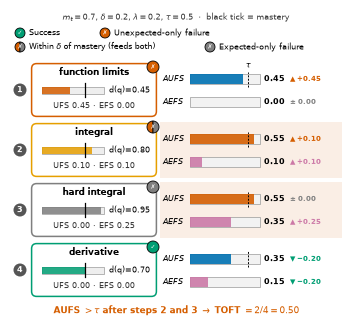

In [6]:
def fig_concept():
    """Figure 1, single column: one row per step (question card on the left, AUFS and AEFS gauges on the right)."""
    mastery, tau = ex_m, TAU
    C_UN, C_BOTH, C_EXP, C_OK, C_LOW, C_AEFS = "#D55E00", "#E69F00", "#7f7f7f", "#009E73", "#0072B2", "#CC79A7"
    KC = {"success": C_OK, "unexpected": C_UN, "both": C_BOTH, "expected": C_EXP}

    def badge(ax, cx, cy, r, kind, fs):
        if kind == "both":
            ax.add_patch(Wedge((cx, cy), r, 90, 270, facecolor=C_UN, edgecolor="black", linewidth=0.6, zorder=6))
            ax.add_patch(Wedge((cx, cy), r, 270, 450, facecolor=C_EXP, edgecolor="black", linewidth=0.6, zorder=6))
        else:
            ax.add_patch(Circle((cx, cy), r, facecolor=KC[kind], edgecolor="black", linewidth=0.6, zorder=6))
        ax.text(cx, cy, "✓" if kind == "success" else "✗", ha="center", va="center", fontsize=fs, color="white", fontweight="bold", zorder=7)

    def dtxt(v, c):
        return (f"▲ +{v:.2f}", c) if v > 1e-9 else ((f"▼ −{abs(v):.2f}", C_OK) if v < -1e-9 else ("± 0.00", "#808080"))

    W, ROW = COL_W, 0.6
    H = 0.5 + 4 * ROW + 0.22
    fig = plt.figure(figsize=(W, H))
    ax = fig.add_axes([0, 0, 1, 1]); ax.set_xlim(0, W); ax.set_ylim(0, H); ax.axis("off")      # axes units are inches
    ax.text(W / 2, H - 0.08, rf"$m_t={mastery:g}$, $\delta={DELTA:g}$, $\lambda={LAM:g}$, $\tau={tau:g}$  ·  black tick = mastery",
            ha="center", va="center", fontsize=5.8, color="#333333")
    for x_, y_, kind, txt in [(0.1, H - 0.23, "success", "Success"), (0.95, H - 0.23, "unexpected", "Unexpected-only failure"),
                              (0.1, H - 0.37, "both", r"Within $\delta$ of mastery (feeds both)"), (2.0, H - 0.37, "expected", "Expected-only failure")]:
        badge(ax, x_, y_, 0.05, kind, 4)
        ax.text(x_ + 0.09, y_, txt, fontsize=5.6, va="center")
    top = H - 0.5
    for k in range(4):
        y0 = top - k * ROW
        gap = ex_diffs[k] - mastery
        kind = "success" if ex_correct[k] else ("unexpected" if gap <= -DELTA else ("expected" if gap >= DELTA else "both"))
        if k in ex_over:      # steps whose AUFS exceeds tau: they count toward TOFT
            ax.add_patch(Rectangle((1.5, y0 - ROW + 0.02), W - 1.51, ROW - 0.04, facecolor=C_UN, alpha=0.10, edgecolor="none", zorder=0))
        ax.add_patch(Circle((0.1, y0 - ROW / 2), 0.065, facecolor="#555555", edgecolor="none", zorder=3))
        ax.text(0.1, y0 - ROW / 2, str(k + 1), ha="center", va="center", fontsize=5.8, color="white", fontweight="bold", zorder=4)
        ax.add_patch(FancyBboxPatch((0.22, y0 - ROW + 0.04), 1.24, ROW - 0.08, boxstyle="round,pad=0.004,rounding_size=0.05",
                                    linewidth=1.1, edgecolor=KC[kind], facecolor="white", zorder=2))
        ax.text(0.84, y0 - 0.12, ex_titles[k], ha="center", va="center", fontsize=6.2, fontweight="bold", zorder=4)
        gx, gw, gy = 0.32, 0.62, y0 - 0.3
        ax.add_patch(Rectangle((gx, gy - 0.035), gw, 0.07, facecolor="#eeeeee", edgecolor="#999999", linewidth=0.5, zorder=3))
        ax.add_patch(Rectangle((gx, gy - 0.035), gw * ex_diffs[k], 0.07, facecolor=KC[kind], edgecolor="none", alpha=0.85, zorder=4))
        ax.plot([gx + gw * mastery] * 2, [gy - 0.07, gy + 0.07], color="black", linewidth=0.9, zorder=5)
        ax.text(gx + gw + 0.05, gy, f"d(q)={ex_diffs[k]:.2f}", ha="left", va="center", fontsize=5.6, zorder=4)
        ax.text(0.84, y0 - 0.46, f"UFS {ex_ufs[k]:.2f} · EFS {ex_efs[k]:.2f}", ha="center", va="center", fontsize=5.6, color="#333333", zorder=4)
        badge(ax, 1.43, y0 - 0.07, 0.06, kind, 4.6)
        for name, yc, val, prev, fillc, incc, thr in [("AUFS", y0 - 0.19, ex_aufs[k + 1], ex_aufs[k], None, C_UN, True),
                                                       ("AEFS", y0 - 0.42, ex_aefs[k + 1], ex_aefs[k], C_AEFS, C_AEFS, False)]:
            bx, bw, bh = 1.8, 0.7, 0.1
            ax.text(1.53, yc, name, ha="left", va="center", fontsize=5.6, style="italic", zorder=4)
            ax.add_patch(Rectangle((bx, yc - bh / 2), bw, bh, facecolor="#f2f2f2", edgecolor="#999999", linewidth=0.5, zorder=3))
            color = (C_UN if val > tau else C_LOW) if thr else fillc
            if val > 0:
                ax.add_patch(Rectangle((bx, yc - bh / 2), bw * min(val, 0.6) / 0.6, bh, facecolor=color, edgecolor="none", alpha=0.9, zorder=4))
            if thr:
                xt = bx + bw * tau / 0.6
                ax.plot([xt, xt], [yc - bh / 2 - 0.025, yc + bh / 2 + 0.025], color="black", linestyle=(0, (2, 1.5)), linewidth=0.7, zorder=5)
                if k == 0:
                    ax.text(xt, yc + bh / 2 + 0.04, r"$\tau$", ha="center", va="bottom", fontsize=5.6, zorder=5)
            ax.text(bx + bw + 0.04, yc, f"{val:.2f}", ha="left", va="center", fontsize=5.8, fontweight="bold", zorder=4)
            t, c = dtxt(val - prev, incc)
            ax.text(bx + bw + 0.3, yc, t, ha="left", va="center", fontsize=5.3, color=c, fontweight="bold", zorder=4)
    steps_txt = " and ".join(str(k + 1) for k in ex_over)
    ax.text(W / 2, 0.11, rf"AUFS $> \tau$ after step{'s' if len(ex_over) > 1 else ''} {steps_txt} $\rightarrow$ TOFT $= {len(ex_over)}/4 = {ex_toft:.2f}$",
            ha="center", va="center", fontsize=6.4, color=C_UN, fontweight="bold")
    finish(fig, "concept_figure")


fig_concept()

## 4. RQ1: failure patterns and mastery trajectories (Sec. 4.2)

### 4a. Learning outcomes (Figure 2)

Learners are grouped by **final estimated mastery**: not mastered ($< 0.70$), partial ($0.70$-$0.85$) and mastered ($\geq 0.90$, the platform's stopping threshold), and compared with the starting pretest bucket.

In [7]:
FINAL_CUTS = (0.70, MASTERY_THRESHOLD)
FINAL_GROUPS = ["not mastered", "partial", "mastered"]
FINAL_COLORS = {"not mastered": "#d9d9d9", "partial": "#969696", "mastered": "#525252"}   # greys: distinct from the bucket colours
FINAL_HATCHES = {"not mastered": "xx", "partial": "..", "mastered": "//"}

fm = pd.DataFrame({
    "traj": range(len(trajectories)), "session_id": [s["id"] for s in session_meta], "bucket": pretest_bucket_of,
    "start": [m[0] for m in skill_progressions_per_batch], "final": [m[-1] for m in skill_progressions_per_batch],
    "n_batches": [len(m) for m in skill_progressions_per_batch],
})
fm["gain"] = fm["final"] - fm["start"]
fm["final_group"] = pd.cut(fm["final"], bins=[-np.inf, FINAL_CUTS[0] - 1e-9, FINAL_CUTS[1] - 1e-9, np.inf], labels=FINAL_GROUPS)

ct = pd.crosstab(fm["bucket"], fm["final_group"]).reindex(index=BUCKETS, columns=FINAL_GROUPS, fill_value=0)
ct.loc["all"] = ct.sum()
print("Sessions: starting bucket (rows) x final-mastery group (columns)")
display(ct)
pct_row = ct.div(ct.sum(axis=1), axis=0) * 100
print("Outcome of each starting bucket (row %):")
display(pct_row.round(1))

R.update({f"final group {g}": int(ct.loc["all", g]) for g in FINAL_GROUPS})
R.update({f"% mastered {b}": pct_row.loc[b, "mastered"] for b in BUCKETS})
R["% partial mid"] = pct_row.loc["mid", "partial"]
R["mean gain low"], R["mean gain high"] = fm.loc[fm.bucket == "low", "gain"].mean(), fm.loc[fm.bucket == "high", "gain"].mean()
R["low learners mastered"] = int(ct.loc["low", "mastered"])
print(f"Mean mastery gain: low {R['mean gain low']:.2f}, mid {fm.loc[fm.bucket == 'mid', 'gain'].mean():.2f}, high {R['mean gain high']:.2f}; "
      f"{R['low learners mastered']} low-skill learners reach mastery.")

Sessions: starting bucket (rows) x final-mastery group (columns)


final_group,not mastered,partial,mastered
bucket,,,
low,14,6,15
mid,7,11,9
high,8,5,22
all,29,22,46


Outcome of each starting bucket (row %):


final_group,not mastered,partial,mastered
bucket,,,
low,40.0,17.1,42.9
mid,25.9,40.7,33.3
high,22.9,14.3,62.9
all,29.9,22.7,47.4


Mean mastery gain: low 0.37, mid 0.35, high 0.30; 15 low-skill learners reach mastery.


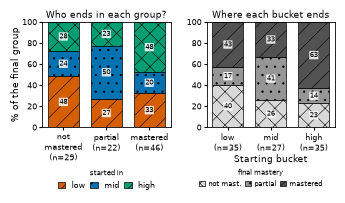

In [8]:
def fig_final_mastery():
    fig, axes = plt.subplots(1, 2, figsize=(COL_W, 1.85))
    ax = axes[0]
    col_tot = ct.drop(index="all").sum(axis=0)
    pct_b = pd.DataFrame({b: (ct.loc[b] / col_tot * 100).reindex(FINAL_GROUPS) for b in BUCKETS}).reindex(FINAL_GROUPS)
    stacked(ax, pct_b, FINAL_GROUPS, BUCKETS, PRETEST_BUCKET_COLORS, PRETEST_BUCKET_HATCHES, {b: b for b in BUCKETS})
    ax.set_xticklabels([f"{g.replace(' ', chr(10))}\n(n={int(col_tot[g])})" for g in FINAL_GROUPS])
    ax.set_ylabel("% of the final group"); ax.set_title("Who ends in each group?")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.33), ncol=3, frameon=False, handlelength=1.0, columnspacing=0.6, title="started in", title_fontsize=5.4)
    ax = axes[1]
    row_tot = ct.drop(index="all").sum(axis=1)
    pct_g = pd.DataFrame({g: ct.loc[BUCKETS, g] / row_tot * 100 for g in FINAL_GROUPS}).reindex(BUCKETS)
    stacked(ax, pct_g, BUCKETS, FINAL_GROUPS, FINAL_COLORS, FINAL_HATCHES, {"not mastered": "not mast.", "partial": "partial", "mastered": "mastered"})
    ax.set_xticklabels([f"{b}\n(n={int(row_tot[b])})" for b in BUCKETS])
    ax.set_xlabel("Starting bucket", labelpad=0.5); ax.set_title("Where each bucket ends")
    ax.legend(loc="upper center", bbox_to_anchor=(0.42, -0.33), ncol=3, frameon=False, handlelength=0.9, columnspacing=0.5, handletextpad=0.4,
              title="final mastery", title_fontsize=5.4, fontsize=5.2)
    fig.subplots_adjust(left=0.115, right=0.995, top=0.91, bottom=0.34, wspace=0.28)
    finish(fig, "final_mastery_by_bucket")


fig_final_mastery()

### 4b. Expected and unexpected failure patterns (Figures 3 and 4)

Bucket-average AUFS and AEFS after each batch (Figure 3), and the composition of failure severity: the *unexpectedness ratio* is the share of a session's total failure severity (positive UFS and EFS contributions, before recovery decay) that is unexpected (Figure 4).

In [9]:
def _ratio_unexpected(u_instants, e_instants):
    u_sev = sum(v for v in u_instants if v > 0)
    e_sev = sum(v for v in e_instants if v > 0)
    return u_sev / (u_sev + e_sev) if u_sev + e_sev > 0 else np.nan


failure_bucket_table = pd.DataFrame([{
    "trajectory_index": i, "pretest_bucket": pretest_bucket_of[i],
    "mean_aufs": np.mean(aufs_progressions[i]), "mean_aefs": np.mean(aefs_progressions[i]),
    "ratio_unexpected": _ratio_unexpected(unexpected_instants_by_session[i], expected_instants_by_session[i]),
} for i in range(len(session_meta))])
failure_bucket_summary = (failure_bucket_table.groupby("pretest_bucket")
                          .agg(n=("trajectory_index", "count"), mean_aufs=("mean_aufs", "mean"), mean_aefs=("mean_aefs", "mean"),
                               mean_ratio_unexpected=("ratio_unexpected", "mean")).reindex(BUCKETS))
display(failure_bucket_summary.round(3))

# end-of-session level of the bucket-average curves (Figure 3)
final_levels = pd.DataFrame({
    "AUFS": {b: np.mean(_pad_sequences([aufs_progressions[i] for i in pretest_buckets[b]], pad_with_last=True), axis=0)[-1] for b in BUCKETS},
    "AEFS": {b: np.mean(_pad_sequences([aefs_progressions[i] for i in pretest_buckets[b]], pad_with_last=True), axis=0)[-1] for b in BUCKETS}})
display(final_levels.round(2))
R.update({f"final AUFS {b}": final_levels.loc[b, "AUFS"] for b in BUCKETS})
R.update({f"final AEFS {b}": final_levels.loc[b, "AEFS"] for b in BUCKETS})
R.update({f"expected share {b}": 100 * (1 - failure_bucket_summary.loc[b, "mean_ratio_unexpected"]) for b in BUCKETS})
print("Expected share of failure severity (%):", {b: round(R[f"expected share {b}"]) for b in BUCKETS})

,n,mean_aufs,mean_aefs,mean_ratio_unexpected
pretest_bucket,,,,
low,35,0.354,1.397,0.349
mid,27,0.287,0.316,0.557
high,35,0.115,0.290,0.508


,AUFS,AEFS
low,0.81,2.04
mid,0.67,0.28
high,0.31,0.31


Expected share of failure severity (%): {'low': 65, 'mid': 44, 'high': 49}


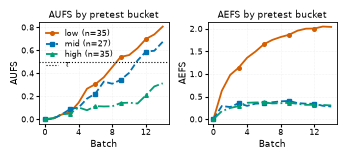

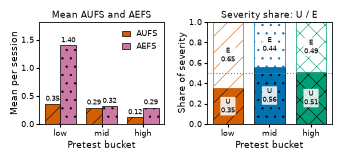

In [10]:
def fig_progression():
    fig, (ax_u, ax_e) = plt.subplots(1, 2, figsize=(COL_W, 1.5))
    ls = {"low": "-", "mid": "--", "high": "-."}; mk = {"low": "o", "mid": "s", "high": "^"}
    for b in BUCKETS:
        idx = pretest_buckets[b]
        for ax, prog in ((ax_u, aufs_progressions), (ax_e, aefs_progressions)):
            y = np.mean(_pad_sequences([prog[i] for i in idx], pad_with_last=True), axis=0)
            ax.plot(y, color=PRETEST_BUCKET_COLORS[b], linestyle=ls[b], marker=mk[b], markevery=3, markersize=2.6, linewidth=1.3, label=f"{b} (n={len(idx)})")
    ax_u.axhline(unexpectedFailure_THRESHOLD, color="black", linestyle=":", linewidth=0.8, label=r"$\tau$")
    ax_u.set_title("AUFS by pretest bucket"); ax_e.set_title("AEFS by pretest bucket")
    ax_u.set_ylabel("AUFS"); ax_e.set_ylabel("AEFS")
    for ax in (ax_u, ax_e):
        ax.set_xlabel("Batch"); ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=5)); ax.grid(linestyle=":", alpha=0.3, linewidth=0.4)
    ax_u.legend(loc="upper left", frameon=False, handlelength=1.6, labelspacing=0.2)
    fig.subplots_adjust(left=0.1, right=0.995, top=0.88, bottom=0.2, wspace=0.3)
    finish(fig, "bucket_aufs_aefs_progression")


def fig_ratio():
    fig, axes = plt.subplots(1, 2, figsize=(COL_W, 1.5))
    ax = axes[0]
    x = np.arange(3); w = 0.38
    au = [failure_bucket_summary.loc[b, "mean_aufs"] for b in BUCKETS]
    ae = [failure_bucket_summary.loc[b, "mean_aefs"] for b in BUCKETS]
    ax.bar(x - w / 2, au, w, color=METRIC_COLORS["aufs"], hatch="//", edgecolor="black", linewidth=0.5, label="AUFS")
    ax.bar(x + w / 2, ae, w, color=METRIC_COLORS["aefs"], hatch="..", edgecolor="black", linewidth=0.5, label="AEFS")
    for xi, (u, e) in enumerate(zip(au, ae)):
        ax.text(xi - w / 2, u + 0.03, f"{u:.2f}", ha="center", va="bottom", fontsize=5)
        ax.text(xi + w / 2, e + 0.03, f"{e:.2f}", ha="center", va="bottom", fontsize=5)
    ax.set_xticks(x); ax.set_xticklabels(BUCKETS); ax.set_ylim(0, max(ae) * 1.3)
    ax.set_xlabel("Pretest bucket"); ax.set_ylabel("Mean per session"); ax.set_title("Mean AUFS and AEFS")
    ax.legend(loc="upper right", frameon=False, handlelength=1.1)
    ax = axes[1]
    ratio = [failure_bucket_summary.loc[b, "mean_ratio_unexpected"] for b in BUCKETS]
    for xi, b in enumerate(BUCKETS):
        col, hat = PRETEST_BUCKET_COLORS[b], PRETEST_BUCKET_HATCHES[b]
        ax.bar(xi, ratio[xi], 0.74, color=col, edgecolor="black", hatch=hat, linewidth=0.5)
        ax.bar(xi, 1 - ratio[xi], 0.74, bottom=ratio[xi], color="white", edgecolor=col, hatch=hat, linewidth=0.5)
        ax.text(xi, ratio[xi] / 2, f"U\n{ratio[xi]:.2f}", **LBL)
        ax.text(xi, ratio[xi] + (1 - ratio[xi]) / 2, f"E\n{1 - ratio[xi]:.2f}", **LBL)
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=0.8)
    ax.set_xticks(range(3)); ax.set_xticklabels(BUCKETS); ax.set_ylim(0, 1)
    ax.set_xlabel("Pretest bucket"); ax.set_ylabel("Share of severity"); ax.set_title("Severity share: U / E")
    fig.subplots_adjust(left=0.115, right=0.995, top=0.88, bottom=0.2, wspace=0.34)
    finish(fig, "unexpectedness_ratio_and_means")


fig_progression()
fig_ratio()

### 4c. Failure patterns at the end of learning (Figure 5)

A failed question of a learner's **last batch** is *unexpected* when UFS $\geq$ EFS and *expected* otherwise; the batch is labelled *no failure*, *unexpected only*, *expected only* or *both*.

,learners
lb_cat,
no failure,25
unexpected only,55
expected only,14
both,3


lb_cat,no failure,unexpected only,expected only,both
bucket,,,,
low,22.9,54.3,20.0,2.9
mid,22.2,63.0,11.1,3.7
high,31.4,54.3,11.4,2.9


lb_cat,no failure,unexpected only,expected only,both
final_group,,,,
not mastered,17.2,75.9,3.4,3.4
partial,9.1,81.8,0.0,9.1
mastered,39.1,32.6,28.3,0.0


72 learners fail in their last batch; 81% of those failed questions are unexpected.


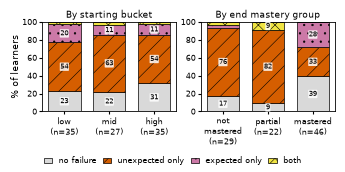

In [11]:
rows = []
for i, steps in enumerate(seqs):
    for bi, step in enumerate(steps):
        n_fail = n_unexp = n_exp = 0
        for correct, g in step:
            if not correct:
                u, e = max(0.0, UFS_DELTA - g), max(0.0, AEFS_DELTA + g)
                n_fail += 1; n_unexp += int(u >= e); n_exp += int(u < e)
        rows.append({"traj": i, "batch": bi, "n_fail": n_fail, "n_unexp": n_unexp, "n_exp": n_exp})
bt = pd.DataFrame(rows)

LB_CATS = ["no failure", "unexpected only", "expected only", "both"]
LB_COLORS = {"no failure": "#d9d9d9", "unexpected only": "#D55E00", "expected only": "#CC79A7", "both": "#F0E442"}
LB_HATCHES = {"no failure": "", "unexpected only": "//", "expected only": "..", "both": "xx"}
last = bt.sort_values("batch").groupby("traj").tail(1).set_index("traj")
last["lb_cat"] = np.where(last["n_fail"] == 0, "no failure", np.where(last["n_exp"] == 0, "unexpected only",
                                                                      np.where(last["n_unexp"] == 0, "expected only", "both")))
last["bucket"] = pd.Series(pretest_bucket_of)
last["final_group"] = fm.set_index("traj")["final_group"]

counts = last["lb_cat"].value_counts().reindex(LB_CATS)
display(counts.to_frame("learners"))
fl = last[last["n_fail"] > 0]
share_unexp_q = fl["n_unexp"].sum() / (fl["n_unexp"].sum() + fl["n_exp"].sum())
by_bucket = pd.crosstab(last["bucket"], last["lb_cat"], normalize="index").reindex(index=BUCKETS, columns=LB_CATS, fill_value=0) * 100
by_final = pd.crosstab(last["final_group"], last["lb_cat"], normalize="index").reindex(index=FINAL_GROUPS, columns=LB_CATS, fill_value=0) * 100
display(by_bucket.round(1)); display(by_final.round(1))
R.update({"last: no failure": int(counts["no failure"]), "last: unexpected only": int(counts["unexpected only"]), "last: expected only": int(counts["expected only"]),
          "learners failing in last batch": len(fl), "% failed questions unexpected (last batch)": 100 * share_unexp_q,
          "unexpected-only % min over buckets": by_bucket["unexpected only"].min(), "unexpected-only % max over buckets": by_bucket["unexpected only"].max(),
          "unexpected-only % not mastered": by_final.loc["not mastered", "unexpected only"], "unexpected-only % partial": by_final.loc["partial", "unexpected only"],
          "no failure % mastered": by_final.loc["mastered", "no failure"]})
print(f"{len(fl)} learners fail in their last batch; {100 * share_unexp_q:.0f}% of those failed questions are unexpected.")


def fig_last_batch():
    fig, axes = plt.subplots(1, 2, figsize=(COL_W, 1.6))
    for ax, (key, order, title) in zip(axes, [("bucket", BUCKETS, "By starting bucket"), ("final_group", FINAL_GROUPS, "By end mastery group")]):
        tab_ = pd.crosstab(last[key], last["lb_cat"]).reindex(index=order, columns=LB_CATS, fill_value=0)
        pct = tab_.div(tab_.sum(axis=1), axis=0) * 100
        stacked(ax, pct, order, LB_CATS, LB_COLORS, LB_HATCHES, {c: c for c in LB_CATS}, minv=8)
        ax.set_xticklabels([f"{str(o).replace(' ', chr(10))}\n(n={int(tab_.loc[o].sum())})" for o in order])
        ax.set_title(title)
    axes[0].set_ylabel("% of learners")
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=4, frameon=False, handlelength=1.1, columnspacing=0.8, fontsize=5.6)
    fig.subplots_adjust(left=0.115, right=0.995, top=0.9, bottom=0.34, wspace=0.18)
    finish(fig, "last_batch_failures")


fig_last_batch()

### 4d. Mastery progression profiles (Figure 6)

Mastery moves in discrete steps, so a session's mastery curve is a staircase. Learners with at least four batches get one of five profiles: **no change**, **one small step** (a single change $\leq 0.10$), **one big jump** (a single change $> 0.10$), **one dominant jump + small steps** (at least two changes, the largest holding $\geq 60\%$ of the total movement) and **several steps**. Sessions with fewer batches are "too short".

In [12]:
MIN_BATCHES_SHAPE, BIG_STEP, DOMINANT_SHARE, EPS_M = 4, 0.10, 0.60, 1e-9
PATTERNS = ["no change", "one small step", "one big jump", "one dominant jump\n+ small steps", "several steps"]
PAT_ALL = PATTERNS + ["too short"]
PAT_COLORS_ALL = dict(zip(PAT_ALL, ["#999999", "#56B4E9", "#0072B2", "#E69F00", "#CC79A7", "#ffffff"]))
PAT_HATCHES_ALL = dict(zip(PAT_ALL, ["", "..", "//", "xx", "\\\\", "||"]))

rows, events = [], []
for i, m in enumerate(skill_progressions_per_batch):
    m = np.asarray(m, float); n = len(m)
    d = np.round(np.diff(m), 4)
    ch = np.where(np.abs(d) > EPS_M)[0]
    sizes = d[ch]
    total_abs = np.abs(d).sum(); max_abs = np.abs(d).max() if len(d) else 0.0
    if n < MIN_BATCHES_SHAPE:        pat = "too short"
    elif len(ch) == 0:               pat = PATTERNS[0]
    elif len(ch) == 1:               pat = PATTERNS[2] if abs(sizes[0]) > BIG_STEP + EPS_M else PATTERNS[1]
    elif max_abs >= DOMINANT_SHARE * total_abs - EPS_M: pat = PATTERNS[3]
    else:                            pat = PATTERNS[4]
    rows.append({"traj": i, "bucket": pretest_bucket_of[i], "n_batches": n, "n_changes": len(ch), "final": m[-1], "max_step": max_abs, "pattern": pat})
    for k in ch:
        events.append({"traj": i, "pattern": pat, "batch": k + 1, "size": d[k]})
ms = pd.DataFrame(rows).set_index("traj")
ev_m = pd.DataFrame(events)
shape = ms[ms["pattern"] != "too short"]

print(f"{len(ev_m)} mastery changes ({int((ev_m['size'] > 0).sum())} increases, {int((ev_m['size'] < 0).sum())} decreases); "
      f"median increase {ev_m.loc[ev_m['size'] > 0, 'size'].median():.2f}; {100 * (ev_m.loc[ev_m['size'] > 0, 'size'] > BIG_STEP).mean():.0f}% of increases exceed {BIG_STEP}")
R["mastery increases"] = int((ev_m["size"] > 0).sum())
R["median increase"] = ev_m.loc[ev_m["size"] > 0, "size"].median()
R["% increases > 0.10"] = 100 * (ev_m.loc[ev_m["size"] > 0, "size"] > BIG_STEP).mean()
R["learners with a shape"] = len(shape)
R.update({f"profile {pname(p)}": int((shape["pattern"] == p).sum()) for p in PATTERNS})
R["too short"] = int((ms["pattern"] == "too short").sum())
print("Profile counts:", {pname(p): R[f"profile {pname(p)}"] for p in PATTERNS}, "| too short:", R["too short"])

ct_p = pd.crosstab(ms["pattern"], ms["bucket"]).reindex(index=PAT_ALL, columns=BUCKETS, fill_value=0)
display(ct_p.rename(index=pname))
R["low one big jump"] = int(ct_p.loc["one big jump", "low"])
chg = shape.groupby("bucket")["n_changes"].mean()
R["changes high"], R["changes low"] = chg["high"], chg["low"]
print(f"Mastery changes per learner: low {chg['low']:.1f}, mid {chg['mid']:.1f}, high {chg['high']:.1f}")


def perm_chi2(label, cols, n_perm=2000, seed=0):
    """Permutation chi-square between the profile (learners with a shape) and a grouping `label` (a column of `shape_x`)."""
    present = [q for q in PATTERNS if (shape_x["pattern"] == q).any()]
    lab, pat = shape_x[label].to_numpy(), shape_x["pattern"].to_numpy()

    def chi(l):
        t = pd.crosstab(pat, l).reindex(index=present, columns=cols, fill_value=0).to_numpy() + 0.0
        return sps.chi2_contingency(t, correction=False)[0]
    obs = chi(lab)
    r = np.random.default_rng(seed)
    null = np.array([chi(r.permutation(lab)) for _ in range(n_perm)])
    return obs, (np.sum(null >= obs) + 1) / (n_perm + 1), np.sqrt(obs / (len(shape_x) * (min(len(present), len(cols)) - 1)))


shape_x = shape.join(fm.set_index("traj")[["final_group"]])
shape_x["final_group"] = shape_x["final_group"].astype(str)
for label, cols, key in [("bucket", BUCKETS, "start bucket"), ("final_group", FINAL_GROUPS, "final mastery")]:
    obs, p_, v_ = perm_chi2(label, cols)
    R[f"profile vs {key}: p"], R[f"profile vs {key}: V"] = p_, v_
    print(f"Profile vs {key}: chi2 = {obs:.1f}, permutation p = {p_:.3f}, Cramer's V = {v_:.2f}")

by_profile = shape.assign(mastered=shape["final"] >= MASTERY_THRESHOLD).groupby("pattern").agg(
    n=("final", "size"), final_mastery=("final", "mean"), pct_mastered=("mastered", "mean"))
by_profile["pct_mastered"] *= 100
display(by_profile.reindex(PATTERNS).rename(index=pname).round(2))
for p_, key in [("one big jump", "big jump"), ("several steps", "several steps")]:
    R[f"final mastery {key}"], R[f"% mastered {key}"] = by_profile.loc[p_, "final_mastery"], by_profile.loc[p_, "pct_mastered"]
R["mastered with no change or one small step"] = int(by_profile.loc[["no change", "one small step"], "pct_mastered"].sum())

187 mastery changes (186 increases, 1 decreases); median increase 0.05; 32% of increases exceed 0.1
Profile counts: {'no change': 3, 'one small step': 7, 'one big jump': 21, 'one dominant jump + small steps': 24, 'several steps': 24} | too short: 18


bucket,low,mid,high
pattern,,,
no change,2,1,0
one small step,1,2,4
one big jump,14,2,5
one dominant jump + small steps,5,11,8
several steps,4,7,13
too short,9,4,5


Mastery changes per learner: low 1.4, mid 2.5, high 2.8


Profile vs start bucket: chi2 = 21.8, permutation p = 0.006, Cramer's V = 0.37


Profile vs final mastery: chi2 = 28.9, permutation p = 0.000, Cramer's V = 0.43


,n,final_mastery,pct_mastered
pattern,,,
no change,3,0.57,0.00
one small step,7,0.58,0.00
one big jump,21,0.70,23.81
one dominant jump + small steps,24,0.80,45.83
several steps,24,0.83,54.17


In [13]:
# ---- unexpected failures and the profiles: final AUFS, and AUFS around the largest mastery increase ----
am = ms[["pattern", "n_batches"]].copy()
am["aufs_final"] = [aufs_progressions[i][-1] for i in am.index]
sh = am[am["pattern"] != "too short"]
display(sh.groupby("pattern")["aufs_final"].agg(["size", "mean", "median"]).reindex(PATTERNS).rename(index=pname).round(2))
kw = sps.kruskal(*[g for g in (sh.loc[sh["pattern"] == q, "aufs_final"] for q in PATTERNS) if len(g) > 2])
R["final AUFS profile KW p"] = kw.pvalue
R["final AUFS one big jump"], R["final AUFS one small step"], R["final AUFS several steps"] = (sh.loc[sh["pattern"] == q, "aufs_final"].mean() for q in ["one big jump", "one small step", "several steps"])
print(f"Final AUFS differs across profiles: Kruskal-Wallis p = {kw.pvalue:.3f}")

ups = ev_m[ev_m["size"] > 0].sort_values(["traj", "size", "batch"], ascending=[True, False, True]).groupby("traj").head(1).set_index("traj")
pre, post = {}, {}
for i, r in ups.iterrows():
    if ms.loc[i, "pattern"] == "too short":
        continue
    a = np.asarray(aufs_progressions[i], float)[: int(ms.loc[i, "n_batches"])]
    j = int(r["batch"])
    if j - 1 >= 0 and j + 2 < len(a):
        pre[i], post[i] = a[j - 1], a[j + 2]
cmp_ = pd.DataFrame({"pattern": ms["pattern"], "before": pd.Series(pre), "after": pd.Series(post)}).dropna()
cmp_["rise"] = cmp_["after"] - cmp_["before"]
display(cmp_.groupby("pattern").agg(n=("rise", "size"), before=("before", "mean"), after=("after", "mean"), rise=("rise", "mean")).reindex(PATTERNS).dropna().rename(index=pname).round(2))
R["AUFS rise after jump"], R["AUFS rise n"] = cmp_["rise"].mean(), len(cmp_)
R["AUFS rise Wilcoxon p"] = sps.wilcoxon(cmp_["rise"]).pvalue
R["AUFS rise after big jumps"] = cmp_.loc[cmp_["pattern"] == "one big jump", "rise"].mean()
print(f"AUFS just before the jump vs two batches after: mean rise {R['AUFS rise after jump']:+.2f} (Wilcoxon p = {R['AUFS rise Wilcoxon p']:.1e}, n = {R['AUFS rise n']}); "
      f"{R['AUFS rise after big jumps']:+.2f} after big jumps")

,size,mean,median
pattern,,,
no change,3,0.52,0.55
one small step,7,1.14,0.20
one big jump,21,1.11,0.40
one dominant jump + small steps,24,0.78,0.20
several steps,24,0.22,0.00


Final AUFS differs across profiles: Kruskal-Wallis p = 0.029


,n,before,after,rise
pattern,,,,
one small step,6.0,0.21,0.33,0.12
one big jump,15.0,0.04,0.57,0.53
one dominant jump + small steps,18.0,0.00,0.34,0.34
several steps,24.0,0.01,0.07,0.05


AUFS just before the jump vs two batches after: mean rise +0.26 (Wilcoxon p = 2.7e-05, n = 63); +0.53 after big jumps


pattern,no change,one small step,one big jump,one dominant jump + small steps,several steps,too short
bucket,,,,,,
low,6.0,3.0,40.0,14.0,11.0,26.0
mid,4.0,7.0,7.0,41.0,26.0,15.0
high,0.0,11.0,14.0,23.0,37.0,14.0


pattern,no change,one small step,one big jump,one dominant jump + small steps,several steps,too short
end_group,,,,,,
not mastered,3.0,24.0,41.0,21.0,7.0,3.0
partial,9.0,0.0,18.0,32.0,41.0,0.0
mastered,0.0,0.0,11.0,24.0,28.0,37.0


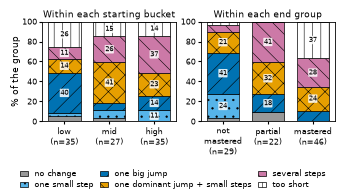

In [14]:
def share_table(key, order):
    counts_ = pd.crosstab(pm[key], pm["pattern"]).reindex(index=order, columns=PAT_ALL, fill_value=0)
    return counts_, counts_.div(counts_.sum(axis=1), axis=0) * 100


pm = ms.join(fm.set_index("traj")[["final_group"]]).rename(columns={"final_group": "end_group"})
pm["end_group"] = pm["end_group"].astype(str)
c_start, pct_start = share_table("bucket", BUCKETS)
c_end, pct_end = share_table("end_group", FINAL_GROUPS)
display(pct_start.round(0).rename(columns=pname)); display(pct_end.round(0).rename(columns=pname))


def fig_profiles():
    fig, axes = plt.subplots(1, 2, figsize=(COL_W, 1.85))
    for ax, pct, cnt, order, title in [(axes[0], pct_start, c_start, BUCKETS, "Within each starting bucket"),
                                         (axes[1], pct_end, c_end, FINAL_GROUPS, "Within each end group")]:
        stacked(ax, pct, order, PAT_ALL, PAT_COLORS_ALL, PAT_HATCHES_ALL, {p: pname(p) for p in PAT_ALL}, minv=11)
        ax.set_xticklabels([f"{str(o).replace(' ', chr(10))}\n(n={int(cnt.loc[o].sum())})" for o in order]); ax.set_title(title)
    axes[0].set_ylabel("% of the group")
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=3, frameon=False, handlelength=1.1, columnspacing=0.8, labelspacing=0.25, fontsize=5.6)
    fig.subplots_adjust(left=0.115, right=0.995, top=0.91, bottom=0.37, wspace=0.18)
    finish(fig, "mastery_profile_shares")


fig_profiles()

## 5. RQ2: failure patterns and self-reported frustration (Sec. 4.3)

### 5a. Self-reported affect and NASA-TLX correlations

Mean NASA-TLX scores (1-7) of the 293 survey administrations by pretest bucket, and the correlations between the five subscales (Pearson below, Spearman above the diagonal of Figure 7a).

In [15]:
bucket_means = survey_rows_bucketed.groupby("pretest_bucket")[SURVEY_SUBSCALES].mean().reindex(BUCKETS)
display(bucket_means.round(2))
for b in BUCKETS:
    R[f"frustration {b}"] = bucket_means.loc[b, "frustration"]
    R[f"perceived performance {b}"] = bucket_means.loc[b, "perceived_performance"]
    R[f"effort {b}"] = bucket_means.loc[b, "effort"]


def corr_with_pvalues(df, method="pearson"):
    cols = df.columns
    r_m = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols)
    p_m = pd.DataFrame(np.zeros((len(cols), len(cols))), index=cols, columns=cols)
    fn = sps.pearsonr if method == "pearson" else sps.spearmanr
    for c1 in cols:
        for c2 in cols:
            if c1 != c2:
                r_m.loc[c1, c2], p_m.loc[c1, c2] = fn(df[c1], df[c2])
    return r_m, p_m


r_pooled, p_pooled = corr_with_pvalues(survey_rows[SURVEY_SUBSCALES], "pearson")
rs_pooled, ps_pooled = corr_with_pvalues(survey_rows[SURVEY_SUBSCALES], "spearman")
R["r frustration vs perceived performance"] = r_pooled.loc["frustration", "perceived_performance"]
R["r frustration vs mental demand"] = r_pooled.loc["frustration", "mental_demand"]
R["r frustration vs temporal demand"] = r_pooled.loc["frustration", "temporal_demand"]
print({k: round(R[k], 2) for k in ["r frustration vs perceived performance", "r frustration vs mental demand", "r frustration vs temporal demand"]})

# Figure 7(a): lower triangle = Pearson, upper triangle = Spearman
_short = {"temporal_demand": "temporal", "mental_demand": "mental", "frustration": "frustration", "perceived_performance": "performance", "effort": "effort"}
_labels = [_short[c] for c in r_pooled.columns]
k_ = len(_labels)
M = np.full((k_, k_), np.nan); P = np.full((k_, k_), np.nan)
for i in range(k_):
    for j in range(k_):
        if i > j:
            M[i, j], P[i, j] = r_pooled.iloc[i, j], p_pooled.iloc[i, j]
        elif i < j:
            M[i, j], P[i, j] = rs_pooled.iloc[i, j], ps_pooled.iloc[i, j]

,temporal_demand,mental_demand,frustration,perceived_performance,effort
pretest_bucket,,,,,
low,3.34,6.27,4.44,2.93,5.52
mid,3.65,5.74,4.58,3.48,5.04
high,3.59,5.49,3.93,4.20,4.86


{'r frustration vs perceived performance': -0.53, 'r frustration vs mental demand': 0.38, 'r frustration vs temporal demand': 0.2}


### 5b. Failure scores and frustration

For every survey, AUFS and AEFS are read at the batch after which the survey was administered. Correlations with frustration are computed per pretest bucket (Figure 7b-c shows AUFS).

In [16]:
sid_to_traj = {s["id"]: i for i, s in enumerate(session_meta)}
rows = []
for r in survey_rows_bucketed.itertuples():
    if pd.isna(r.batch_index_at_trigger):
        continue
    ti, b = sid_to_traj.get(r.session_id), int(r.batch_index_at_trigger)
    if ti is None or not (0 <= b < len(aufs_progressions[ti])):
        continue
    rows.append({"trajectory_index": ti, "session_id": r.session_id, "administration_index": r.administration_index, "pretest_bucket": r.pretest_bucket,
                 "batch": b, "frustration": r.frustration, "aufs_at_trigger": aufs_progressions[ti][b], "aefs_at_trigger": aefs_progressions[ti][b]})
frustration_aufs = pd.DataFrame(rows)
print(f"Matched {len(frustration_aufs)} of {len(survey_rows_bucketed)} survey administrations to an AUFS / AEFS value.")

pearson_r, pearson_p = sps.pearsonr(frustration_aufs["frustration"], frustration_aufs["aufs_at_trigger"])
print(f"All surveys: AUFS vs frustration Pearson r = {pearson_r:.2f} (p = {pearson_p:.4f})")
corr_rows = []
for b in BUCKETS:
    d = frustration_aufs[frustration_aufs["pretest_bucket"] == b]
    r, p = sps.pearsonr(d["frustration"], d["aufs_at_trigger"]); rs, ps = sps.spearmanr(d["frustration"], d["aufs_at_trigger"])
    re_, pe_ = sps.spearmanr(d["frustration"], d["aefs_at_trigger"])
    corr_rows.append({"bucket": b, "n": len(d), "AUFS Pearson r": r, "p": p, "AUFS Spearman rho": rs, "p (S)": ps, "AEFS Spearman rho": re_, "p (AEFS)": pe_})
    R[f"AUFS r {b}"], R[f"AUFS r p {b}"], R[f"AUFS rho {b}"], R[f"AUFS rho p {b}"], R[f"AEFS rho {b}"] = r, p, rs, ps, re_
display(pd.DataFrame(corr_rows).set_index("bucket").round(4))

Matched 293 of 293 survey administrations to an AUFS / AEFS value.
All surveys: AUFS vs frustration Pearson r = 0.18 (p = 0.0024)


,n,AUFS Pearson r,p,AUFS Spearman rho,p (S),AEFS Spearman rho,p (AEFS)
bucket,,,,,,,
low,124,-0.0456,0.6148,-0.0234,0.7968,-0.0199,0.8260
mid,100,0.3873,0.0001,0.3988,0.0000,0.3379,0.0006
high,69,0.2814,0.0192,0.3759,0.0015,0.3435,0.0039


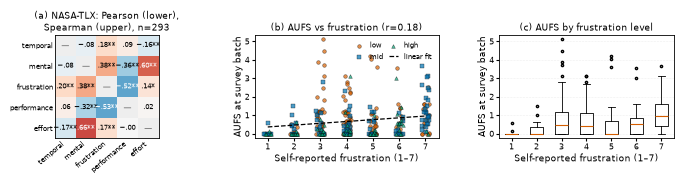

In [17]:
def fig_rq2():
    """Figure 7 (full width): (a) NASA-TLX correlations, (b) AUFS vs frustration, (c) AUFS by frustration level."""
    fig = plt.figure(figsize=(WIDE_W, 1.85))
    gs = fig.add_gridspec(1, 3, width_ratios=[0.95, 1, 0.95], left=0.06, right=0.995, top=0.86, bottom=0.3, wspace=0.34)
    ax = fig.add_subplot(gs[0])
    cmap = plt.get_cmap("RdBu_r").copy(); cmap.set_bad("#eeeeee")
    ax.imshow(np.ma.masked_invalid(M), vmin=-1, vmax=1, cmap=cmap)
    for i in range(k_):
        for j in range(k_):
            if np.isnan(M[i, j]):
                ax.text(j, i, "—", ha="center", va="center", fontsize=5.5, color="#888888"); continue
            star = "**" if P[i, j] < 0.01 else ("*" if P[i, j] < 0.05 else "")
            ax.text(j, i, f"{M[i, j]:.2f}{star}".replace("0.", ".").replace("-.", "−."), ha="center", va="center", fontsize=4.9,
                    color="white" if abs(M[i, j]) > 0.5 else "black")
    ax.set_xticks(range(k_)); ax.set_xticklabels(_labels, rotation=40, ha="right", fontsize=5.4)
    ax.set_yticks(range(k_)); ax.set_yticklabels(_labels, fontsize=5.4)
    ax.set_title(f"(a) NASA-TLX: Pearson (lower),\nSpearman (upper), n={len(survey_rows)}", fontsize=6.3)
    ax.tick_params(length=0)
    fa = frustration_aufs.copy()
    rng = np.random.default_rng(0)
    fa["fj"] = fa["frustration"] + rng.uniform(-0.15, 0.15, size=len(fa))
    ax = fig.add_subplot(gs[1])
    for b, col in PRETEST_BUCKET_COLORS.items():
        d = fa[fa["pretest_bucket"] == b]
        ax.scatter(d["fj"], d["aufs_at_trigger"], color=col, marker={"low": "o", "mid": "s", "high": "^"}[b], edgecolor="black", linewidth=0.3, alpha=0.7, s=7, label=b)
    cf = np.polyfit(fa["frustration"], fa["aufs_at_trigger"], 1); xs = np.linspace(1, 7, 50)
    ax.plot(xs, np.polyval(cf, xs), "k--", linewidth=0.9, label="linear fit")
    ax.set_xlabel("Self-reported frustration (1–7)"); ax.set_ylabel("AUFS at survey batch")
    ax.set_title(f"(b) AUFS vs frustration (r={pearson_r:.2f})"); ax.set_xlim(0.5, 7.5)
    ax.legend(loc="upper right", ncol=2, frameon=False, handlelength=1.2, columnspacing=0.8, fontsize=5.4)
    ax = fig.add_subplot(gs[2])
    lv = sorted(fa["frustration"].unique())
    ax.boxplot([fa.loc[fa["frustration"] == v, "aufs_at_trigger"] for v in lv], tick_labels=[int(v) for v in lv],
               flierprops=dict(marker="o", markersize=1.6), boxprops=dict(linewidth=0.6), medianprops=dict(linewidth=0.8, color="#D55E00"),
               whiskerprops=dict(linewidth=0.6), capprops=dict(linewidth=0.6))
    ax.set_xlabel("Self-reported frustration (1–7)"); ax.set_ylabel("AUFS at survey batch"); ax.set_title("(c) AUFS by frustration level")
    ax.grid(axis="y", linestyle=":", alpha=0.4, linewidth=0.4)
    finish(fig, "rq2_frustration")


fig_rq2()

## 6. RQ3: does unexpectedness explain frustration beyond the number of failures? (Sec. 4.4)

At every survey, for the answers given so far: **failures** is the cumulative number of failed questions and **unexpectedness** is the share of the accumulated failure severity that is unexpected, $\sum UFS / (\sum UFS + \sum EFS)$ (with $\delta = 0.20$ and strict EFS). It is undefined before the first failure, so surveys without any failure are left out. Standard errors are clustered by session because a learner contributes up to 11 surveys.

1. *Same failures, different unexpectedness* (Figure 8a): surveys are split into three bands of cumulative failures, and within each band those with above-median unexpectedness are compared with the others.
2. *Regressions* $\text{Frustration} = \beta_0 + \beta_1\,\text{Failures} + \beta_2\,\text{Unexpectedness}$ on standardised predictors, with controls, alternative measures, learner fixed effects and one fit per bucket (Figure 8b).

In [18]:
# ---- surveys with the failure measures accumulated up to their batch ----
sv = frustration_aufs.rename(columns={"trajectory_index": "traj", "pretest_bucket": "bucket"})

rows = []
for i, steps in enumerate(seqs):
    U = E = 0.0; nf = nu = nq = 0
    for bi, step in enumerate(steps):
        for correct, g in step:
            nq += 1
            if not correct:
                u, e = max(0.0, UFS_DELTA - g), max(0.0, AEFS_DELTA + g)
                U += u; E += e; nf += 1; nu += int(u >= e)
        rows.append({"traj": i, "batch": bi, "U": U, "E": E, "nf": nf, "nu": nu, "nq": nq})
cum_ = pd.DataFrame(rows).set_index(["traj", "batch"])

q = sv.join(cum_, on=["traj", "batch"]).copy()
q["failures"] = q["nf"].astype(float)
q["answered"] = q["nq"].astype(float)
q["unexp_ratio"] = q["U"] / (q["U"] + q["E"]).replace(0, np.nan)
q["unexp_share"] = q["nu"] / q["nf"].replace(0, np.nan)
q["aufs_s"] = [aufs_progressions[t][b] for t, b in zip(q["traj"], q["batch"])]
q["mastery"] = [skill_progressions_per_batch[t][b] for t, b in zip(q["traj"], q["batch"])]
q["bucket_low"] = (q["bucket"] == "low").astype(float); q["bucket_mid"] = (q["bucket"] == "mid").astype(float)
n_all = len(q)
q = q[(q["failures"] >= 1) & q["unexp_ratio"].notna()].reset_index(drop=True)
R["RQ3 surveys used"], R["RQ3 learners"] = len(q), q["session_id"].nunique()
R["rho failures~unexpectedness"] = sps.spearmanr(q["failures"], q["unexp_ratio"])[0]
R["rho unexpectedness~frustration"] = sps.spearmanr(q["unexp_ratio"], q["frustration"])[0]
print(f"{len(q)} of {n_all} surveys have at least one failure so far ({q['session_id'].nunique()} learners)")
print(f"Spearman: failures~unexpectedness {R['rho failures~unexpectedness']:+.2f}, failures~frustration {sps.spearmanr(q['failures'], q['frustration'])[0]:+.2f}, "
      f"unexpectedness~frustration {R['rho unexpectedness~frustration']:+.2f}")

# ---- 1. same failures, different unexpectedness ----
q["f_band"] = pd.qcut(q["failures"], 3, labels=False, duplicates="drop")
band_names = {b_: f"{int(d_['failures'].min())}-{int(d_['failures'].max())}" for b_, d_ in q.groupby("f_band")}
q["u_group"] = "low"
for b_, d_ in q.groupby("f_band"):
    q.loc[d_.index[d_["unexp_ratio"] > d_["unexp_ratio"].median()], "u_group"] = "high"
BANDS = sorted(q["f_band"].unique())
display(q.groupby(["f_band", "u_group"]).agg(n=("frustration", "size"), learners=("session_id", "nunique"), failures=("failures", "mean"),
                                              unexpectedness=("unexp_ratio", "mean"), answered=("answered", "mean"), frustration=("frustration", "mean")).round(2))

groups = [g.index.to_numpy() for _, g in q.groupby("session_id")]
frus = q["frustration"].to_numpy(); band = q["f_band"].to_numpy(); hi = (q["u_group"] == "high").to_numpy()


def strat_stats(idx):
    out, w = {}, {}
    for b_ in BANDS:
        m = band[idx] == b_
        h, l = frus[idx][m & hi[idx]], frus[idx][m & ~hi[idx]]
        if len(h) and len(l):
            out[b_] = (h.mean(), l.mean()); w[b_] = m.sum()
    return out, (sum(w[b_] * (out[b_][0] - out[b_][1]) for b_ in out) / sum(w.values()) if out else np.nan)


point, pooled_pt = strat_stats(np.arange(len(q)))
rng = np.random.default_rng(0)
boot_cells = {b_: [] for b_ in BANDS}; boot_pooled = []
for _ in range(1000):
    idx = np.concatenate([groups[k] for k in rng.integers(0, len(groups), len(groups))])
    s_, pooled = strat_stats(idx)
    boot_pooled.append(pooled)
    for b_ in BANDS:
        if b_ in s_:
            boot_cells[b_].append(s_[b_])
lo, hi_ = np.nanpercentile(boot_pooled, [2.5, 97.5])
R["pooled difference"], R["pooled difference lo"], R["pooled difference hi"] = pooled_pt, lo, hi_
print(f"Pooled difference (higher - lower unexpectedness) at the same failure count: {pooled_pt:+.2f} [{lo:+.2f}, {hi_:+.2f}]")

280 of 293 surveys have at least one failure so far (90 learners)
Spearman: failures~unexpectedness +0.07, failures~frustration +0.25, unexpectedness~frustration -0.04


n  learners  failures  unexpectedness  answered  frustration
f_band u_group                                                               
0      high     51        33      4.73            0.72     24.06         4.04
       low      51        46      3.65            0.09     13.59         3.82
1      high     42        24     12.98            0.68     34.57         4.48
       low      43        29     11.88            0.22     20.65         4.58
2      high     46        22     24.39            0.59     39.26         4.65
       low      47        19     23.87            0.24     35.87         5.04

Pooled difference (higher - lower unexpectedness) at the same failure count: -0.08 [-0.65, +0.52]


In [19]:
# ---- 2. regressions on standardised predictors, session-clustered standard errors ----
def ols_cluster(df, y, xcols, cluster="session_id"):
    X = np.column_stack([np.ones(len(df))] + [df[c].astype(float).to_numpy() for c in xcols])
    yv = df[y].astype(float).to_numpy()
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ yv
    resid = yv - X @ beta
    g = df[cluster].to_numpy(); ug = np.unique(g)
    meat = np.zeros((X.shape[1], X.shape[1]))
    for gi in ug:
        s = X[g == gi].T @ resid[g == gi]
        meat += np.outer(s, s)
    n, k, G = len(yv), X.shape[1], len(ug)
    V = (G / (G - 1)) * ((n - 1) / (n - k)) * XtX_inv @ meat @ XtX_inv
    se = np.sqrt(np.diag(V))
    p = 2 * sps.t.sf(np.abs(beta / se), df=G - 1)
    tcrit = sps.t.ppf(0.975, G - 1)
    return pd.DataFrame({"coef": beta, "se": se, "p": p, "lo": beta - tcrit * se, "hi": beta + tcrit * se}, index=["intercept"] + xcols), n, G


def zscore(df, cols):
    out = df.copy()
    for c in cols:
        sd = out[c].std()
        out[c] = (out[c] - out[c].mean()) / sd if sd > 0 else 0.0
    return out


def r2(df, y, xs):
    X = np.column_stack([np.ones(len(df))] + [df[c].to_numpy(float) for c in xs])
    yv = df[y].to_numpy(float)
    res = yv - X @ np.linalg.lstsq(X, yv, rcond=None)[0]
    return 1 - (res @ res) / ((yv - yv.mean()) @ (yv - yv.mean()))


ZCOLS = ["failures", "answered", "unexp_ratio", "unexp_share", "aufs_s", "mastery"]
zq = zscore(q, ZCOLS)
CTRL = ["bucket_low", "bucket_mid"]
SPECS = [
    ("failures only",                              ["failures"], None),
    ("+ unexpectedness",                           ["failures", "unexp_ratio"], "unexp_ratio"),
    ("+ answers so far, bucket",                   ["failures", "unexp_ratio", "answered"] + CTRL, "unexp_ratio"),
    ("+ answers so far, bucket, mastery",          ["failures", "unexp_ratio", "answered", "mastery"] + CTRL, "unexp_ratio"),
    ("share of failed questions (count-based)",    ["failures", "unexp_share", "answered"] + CTRL, "unexp_share"),
    ("AUFS instead of the ratio",                  ["failures", "aufs_s", "answered"] + CTRL, "aufs_s"),
]
coef_rows, forest = [], []
for name, xs_, focus in SPECS:
    res, n, G = ols_cluster(zq, "frustration", xs_)
    row = {"model": name, "R2": r2(zq, "frustration", xs_), "beta Failures": f"{res.loc['failures', 'coef']:+.2f} [{res.loc['failures', 'lo']:+.2f}, {res.loc['failures', 'hi']:+.2f}]"}
    R[f"beta failures: {name}"] = tuple(res.loc["failures", ["coef", "lo", "hi"]])
    R[f"R2: {name}"] = row["R2"]
    if focus:
        r_ = res.loc[focus]
        row["beta Unexpectedness"] = f"{r_['coef']:+.2f} [{r_['lo']:+.2f}, {r_['hi']:+.2f}]"; row["p"] = r_["p"]
        forest.append((name, r_["coef"], r_["lo"], r_["hi"]))
        R[f"beta unexpectedness: {name}"] = (r_["coef"], r_["lo"], r_["hi"], r_["p"])
    coef_rows.append(row)
display(pd.DataFrame(coef_rows).set_index("model").round(3))
print(f"({n} surveys, {G} learners; predictors standardised: coefficients are frustration points per 1 SD)")

base_x, full_x = ["failures", "answered"] + CTRL, ["failures", "unexp_ratio", "answered"] + CTRL
rng = np.random.default_rng(1); gains = []
for _ in range(500):
    d = zq.loc[np.concatenate([groups[k] for k in rng.integers(0, len(groups), len(groups))])].reset_index(drop=True)
    gains.append(r2(d, "frustration", full_x) - r2(d, "frustration", base_x))
lo, hi_ = np.percentile(gains, [2.5, 97.5])
R["delta R2"], R["delta R2 lo"], R["delta R2 hi"] = r2(zq, "frustration", full_x) - r2(zq, "frustration", base_x), lo, hi_
print(f"R2 gain from adding unexpectedness to failures + answers + bucket: {R['delta R2']:+.3f} (bootstrap 95% CI [{lo:+.3f}, {hi_:+.3f}])")

# within-learner version (each learner's own mean removed = learner fixed effects)
w = q[q.groupby("session_id")["frustration"].transform("size") >= 2].copy()
for c_ in ["frustration", "failures", "unexp_ratio", "answered"]:
    w[c_] = w[c_] - w.groupby("session_id")[c_].transform("mean")
wz = zscore(w, ["failures", "unexp_ratio", "answered"])
res, n_w, G_w = ols_cluster(wz, "frustration", ["failures", "unexp_ratio", "answered"])
r_ = res.loc["unexp_ratio"]
R["beta unexpectedness: within learner"] = (r_["coef"], r_["lo"], r_["hi"], r_["p"])
forest.append(("within learner (fixed effects)", r_["coef"], r_["lo"], r_["hi"]))
print(f"Within learner ({n_w} surveys, {G_w} learners): beta Unexpectedness = {r_['coef']:+.2f} [{r_['lo']:+.2f}, {r_['hi']:+.2f}], p = {r_['p']:.3f}")

# one fit per pretest bucket
bk_rows = []
for b in BUCKETS:
    zb = zscore(q[q["bucket"] == b].reset_index(drop=True), ZCOLS)
    res, n_b, G_b = ols_cluster(zb, "frustration", ["failures", "unexp_ratio", "answered"])
    r_ = res.loc["unexp_ratio"]
    bk_rows.append({"bucket": b, "surveys": n_b, "learners": G_b, "beta Failures": res.loc["failures", "coef"], "beta Unexpectedness": r_["coef"],
                    "95% CI": f"[{r_['lo']:+.2f}, {r_['hi']:+.2f}]", "p": r_["p"]})
    forest.append((f"{b} bucket only", r_["coef"], r_["lo"], r_["hi"]))
    R[f"beta unexpectedness: {b} bucket"] = r_["coef"]
display(pd.DataFrame(bk_rows).set_index("bucket").round(3))

,R2,beta Failures,beta Unexpectedness,p
model,,,,
failures only,0.066,"+0.44 [+0.08, +0.79]",NaN,NaN
+ unexpectedness,0.068,"+0.44 [+0.08, +0.79]","-0.08 [-0.38, +0.22]",0.583
"+ answers so far, bucket",0.110,"+0.86 [+0.24, +1.47]","+0.11 [-0.28, +0.50]",0.569
"+ answers so far, bucket, mastery",0.111,"+0.85 [+0.22, +1.48]","+0.12 [-0.27, +0.51]",0.545
share of failed questions (count-based),0.114,"+0.85 [+0.26, +1.44]","+0.17 [-0.22, +0.55]",0.396
AUFS instead of the ratio,0.109,"+0.88 [+0.26, +1.50]","-0.11 [-0.70, +0.48]",0.709


(280 surveys, 90 learners; predictors standardised: coefficients are frustration points per 1 SD)


R2 gain from adding unexpectedness to failures + answers + bucket: +0.003 (bootstrap 95% CI [+0.000, +0.052])
Within learner (246 surveys, 56 learners): beta Unexpectedness = +0.14 [-0.03, +0.31], p = 0.096


,surveys,learners,beta Failures,beta Unexpectedness,95% CI,p
bucket,,,,,,
low,121,33,0.382,-0.008,"[-0.53, +0.52]",0.977
mid,98,26,1.394,0.199,"[-0.66, +1.05]",0.636
high,61,31,0.874,0.215,"[-0.32, +0.75]",0.415


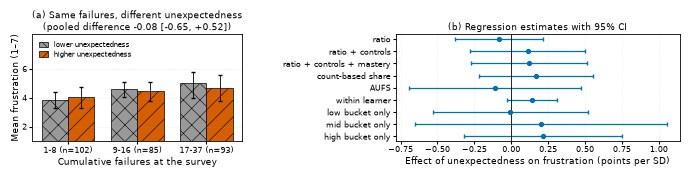

In [20]:
def fig_rq3():
    """Figure 8 (full width): (a) frustration at comparable failure counts, (b) regression estimates."""
    fig = plt.figure(figsize=(WIDE_W, 1.75))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.35], left=0.065, right=0.99, top=0.86, bottom=0.25, wspace=0.62)
    ax = fig.add_subplot(gs[0])
    xs = np.arange(len(BANDS)); wd = 0.38
    for k, (col, hat, lab) in enumerate([("#999999", "xx", "lower unexpectedness"), ("#D55E00", "//", "higher unexpectedness")]):
        vals = np.array([point[b_][1 - k] for b_ in BANDS])
        ci = np.array([np.nanpercentile([c[1 - k] for c in boot_cells[b_]], [2.5, 97.5]) for b_ in BANDS])
        ax.bar(xs + (k - 0.5) * wd, vals, wd, color=col, edgecolor="black", hatch=hat, label=lab, linewidth=0.5,
               yerr=[vals - ci[:, 0], ci[:, 1] - vals], capsize=1.5, error_kw=dict(linewidth=0.6))
    ax.set_xticks(xs); ax.set_xticklabels([f"{band_names[b_]} (n={int((band == b_).sum())})" for b_ in BANDS])
    ax.set_xlabel("Cumulative failures at the survey"); ax.set_ylabel("Mean frustration (1–7)"); ax.set_ylim(1, 8.4); ax.set_yticks([2, 4, 6])
    ax.set_title(f"(a) Same failures, different unexpectedness\n(pooled difference {pooled_pt:+.2f} [{np.nanpercentile(boot_pooled, 2.5):+.2f}, {np.nanpercentile(boot_pooled, 97.5):+.2f}])", fontsize=6.3)
    ax.legend(fontsize=5.4, loc="upper left", ncol=1, frameon=False, handlelength=1.2, labelspacing=0.25)
    ax.grid(axis="y", linestyle=":", alpha=0.4, linewidth=0.4)
    ax = fig.add_subplot(gs[1])
    short = {"+ unexpectedness": "ratio", "+ answers so far, bucket": "ratio + controls", "+ answers so far, bucket, mastery": "ratio + controls + mastery",
             "share of failed questions (count-based)": "count-based share", "AUFS instead of the ratio": "AUFS", "within learner (fixed effects)": "within learner"}
    labels = [short.get(f[0], f[0]) for f in forest]; ys = np.arange(len(forest))[::-1]
    for y, (_, c_, lo_, hi_) in zip(ys, forest):
        ax.errorbar(c_, y, xerr=[[c_ - lo_], [hi_ - c_]], fmt="o", color="#0072B2", capsize=1.5, markersize=2.8, linewidth=0.9)
    ax.axvline(0, color="black", linewidth=0.6)
    ax.set_yticks(ys); ax.set_yticklabels(labels)
    ax.set_xlabel("Effect of unexpectedness on frustration (points per SD)")
    ax.set_title("(b) Regression estimates with 95% CI"); ax.grid(axis="x", linestyle=":", alpha=0.4, linewidth=0.4)
    finish(fig, "rq3_unexpectedness_given_failures")


fig_rq3()

## 7. Check against the paper

Every number quoted in the text is listed with its value in the paper and the value computed above (`PASS` when the two agree at the precision printed in the paper). Anything marked `DIFF` points at a sentence of the paper that needs updating, or at a change in the data or code.

In [21]:
def close(a, b, tol):
    """The paper prints rounded values: a computed number matches when it rounds to the printed one (or lies within the absolute tolerance tol, used for the 'about' claims)."""
    a, b = float(a), float(b)
    txt = f"{a:.10g}"
    decimals = len(txt.split(".")[1]) if "." in txt else 0
    return abs(round(b, decimals) - a) < 1e-9 or abs(a - b) <= tol


# (label, value in the paper, computed value, tolerance)
claims = [
    # Sec. 4.1
    ("sessions recorded", 144, R["sessions recorded"], 0), ("completed", 97, R["completed"], 0), ("abandoned early", 34, R["abandoned early"], 0),
    ("did not progress beyond the pretest", 9, R["stuck in the pretest"], 0), ("stopped during learning", 4, R["stopped during learning"], 0),
    ("participants low / medium / high", (35, 27, 35), (R["bucket low"], R["bucket mid"], R["bucket high"]), 0),
    ("HC-fixed / HC-threshold / MAB-fixed / MAB-threshold", (26, 24, 22, 25),
     (R["HC fixed_count"], R["HC fixed_count_or_threshold"], R["MAB fixed_count"], R["MAB fixed_count_or_threshold"]), 0),
    ("survey administrations", 293, R["surveys"], 0),
    # RQ1: learning outcomes
    ("final groups not mastered / partial / mastered", (29, 22, 46), (R["final group not mastered"], R["final group partial"], R["final group mastered"]), 0),
    ("% reaching mastery: high / low / medium", (63, 43, 33), (R["% mastered high"], R["% mastered low"], R["% mastered mid"]), 0.5),
    ("medium-skill with partial mastery (%)", 41, R["% partial mid"], 0.5),
    ("mean mastery gain low / high", (0.37, 0.30), (R["mean gain low"], R["mean gain high"]), 0.005),
    ("low-skill learners reaching mastery", 15, R["low learners mastered"], 0),
    # RQ1: failure patterns
    ("end-of-session AUFS low / mid / high (about)", (0.8, 0.7, 0.3), (R["final AUFS low"], R["final AUFS mid"], R["final AUFS high"]), 0.06),
    ("end-of-session AEFS low / mid / high (about)", (2.0, 0.3, 0.3), (R["final AEFS low"], R["final AEFS mid"], R["final AEFS high"]), 0.1),
    ("expected share of failure severity low / mid / high (%)", (65, 44, 49), (R["expected share low"], R["expected share mid"], R["expected share high"]), 0.5),
    # RQ1: last batch
    ("last batch: no failure / unexpected only / expected only", (25, 55, 14), (R["last: no failure"], R["last: unexpected only"], R["last: expected only"]), 0),
    ("learners failing in the last batch", 72, R["learners failing in last batch"], 0),
    ("failed questions classified unexpected (%)", 81, R["% failed questions unexpected (last batch)"], 0.5),
    ("unexpected-only final batches across starting groups (%)", (54, 63), (R["unexpected-only % min over buckets"], R["unexpected-only % max over buckets"]), 0.5),
    ("unexpected-only: not mastered / partial (%)", (76, 82), (R["unexpected-only % not mastered"], R["unexpected-only % partial"]), 0.5),
    ("no failure among mastered (%)", 39, R["no failure % mastered"], 0.5),
    # RQ1: mastery profiles
    ("mastery increases", 186, R["mastery increases"], 0), ("median increase", 0.05, R["median increase"], 0.005), ("increases above 0.10 (%)", 32, R["% increases > 0.10"], 0.5),
    ("learners with at least 4 batches", 79, R["learners with a shape"], 0),
    ("profiles: no change / small step / big jump / dominant / several", (3, 7, 21, 24, 24),
     tuple(R[f"profile {pname(p)}"] for p in PATTERNS), 0),
    ("sessions too short", 18, R["too short"], 0),
    ("profile vs starting skill: p, V", (0.006, 0.37), (R["profile vs start bucket: p"], R["profile vs start bucket: V"]), 0.004),
    ("low-skill learners with one big jump", 14, R["low one big jump"], 0),
    ("changes per learner high / low", (2.8, 1.4), (R["changes high"], R["changes low"]), 0.05),
    ("profile vs final mastery: V (p < 0.001)", 0.43, R["profile vs final mastery: V"], 0.005),
    ("one big jump: final mastery, % mastered", (0.70, 24), (R["final mastery big jump"], R["% mastered big jump"]), 0.5),
    ("several steps: final mastery, % mastered", (0.83, 54), (R["final mastery several steps"], R["% mastered several steps"]), 0.5),
    ("no change / one small step reaching mastery", 0, R["mastered with no change or one small step"], 0),
    ("final AUFS across profiles: Kruskal-Wallis p", 0.029, R["final AUFS profile KW p"], 0.002),
    ("final AUFS: one big jump / one small step / several steps", (1.11, 1.14, 0.22),
     (R["final AUFS one big jump"], R["final AUFS one small step"], R["final AUFS several steps"]), 0.006),
    ("AUFS rise within two batches after the largest increase, n", (0.26, 63), (R["AUFS rise after jump"], R["AUFS rise n"]), 0.006),
    ("AUFS rise after big jumps", 0.53, R["AUFS rise after big jumps"], 0.006),
    # RQ2
    ("mean frustration low / medium / high", (4.44, 4.58, 3.93), (R["frustration low"], R["frustration mid"], R["frustration high"]), 0.006),
    ("perceived performance low / medium / high", (2.93, 3.48, 4.20), (R["perceived performance low"], R["perceived performance mid"], R["perceived performance high"]), 0.006),
    ("effort low / medium / high", (5.52, 5.04, 4.86), (R["effort low"], R["effort mid"], R["effort high"]), 0.006),
    ("r(frustration, perceived performance / mental / temporal demand)", (-0.53, 0.38, 0.20),
     (R["r frustration vs perceived performance"], R["r frustration vs mental demand"], R["r frustration vs temporal demand"]), 0.006),
    ("AUFS~frustration, medium: Pearson r, Spearman rho", (0.39, 0.40), (R["AUFS r mid"], R["AUFS rho mid"]), 0.006),
    ("AUFS~frustration, high: Pearson r, Spearman rho", (0.28, 0.38), (R["AUFS r high"], R["AUFS rho high"]), 0.006),
    ("AUFS~frustration, low: Pearson r (p = 0.61)", (-0.05, 0.61), (R["AUFS r low"], R["AUFS r p low"]), 0.006),
    ("AEFS~frustration Spearman medium / high / low", (0.34, 0.34, -0.02), (R["AEFS rho mid"], R["AEFS rho high"], R["AEFS rho low"]), 0.006),
    # RQ3
    ("surveys used, learners", (280, 90), (R["RQ3 surveys used"], R["RQ3 learners"]), 0),
    ("beta failures alone [CI], R2", (0.44, 0.08, 0.79, 0.066), (*R["beta failures: failures only"], R["R2: failures only"]), 0.006),
    ("rho failures~unexpectedness, unexpectedness~frustration", (0.07, -0.04), (R["rho failures~unexpectedness"], R["rho unexpectedness~frustration"]), 0.006),
    ("beta unexpectedness [CI]", (-0.08, -0.38, 0.22), R["beta unexpectedness: + unexpectedness"][:3], 0.006),
    ("delta R2 [CI]", (0.003, 0.000, 0.052), (R["delta R2"], R["delta R2 lo"], R["delta R2 hi"]), 0.0035),
    ("pooled difference [CI]", (-0.08, -0.65, 0.52), (R["pooled difference"], R["pooled difference lo"], R["pooled difference hi"]), 0.006),
    ("controls: beta unexpectedness [CI]", (0.11, -0.28, 0.50), R["beta unexpectedness: + answers so far, bucket"][:3], 0.006),
    ("+ mastery: beta unexpectedness [CI]", (0.12, -0.27, 0.51), R["beta unexpectedness: + answers so far, bucket, mastery"][:3], 0.006),
    ("beta failures with controls [CI]", (0.86, 0.24, 1.47), R["beta failures: + answers so far, bucket"], 0.006),
    ("count-based share [CI]", (0.17, -0.22, 0.55), R["beta unexpectedness: share of failed questions (count-based)"][:3], 0.006),
    ("AUFS instead of the ratio [CI]", (-0.11, -0.70, 0.48), R["beta unexpectedness: AUFS instead of the ratio"][:3], 0.006),
    ("per bucket: low / medium / high", (-0.01, 0.20, 0.22), (R["beta unexpectedness: low bucket"], R["beta unexpectedness: mid bucket"], R["beta unexpectedness: high bucket"]), 0.006),
    ("within learner [CI], p", (0.14, -0.03, 0.31, 0.096), R["beta unexpectedness: within learner"], 0.0035),
    # Figure 1
    ("running example: TOFT", 0.50, R["example TOFT"], 1e-9),
]

rows = []
for label, paper, computed, tol in claims:
    p_, c_ = np.atleast_1d(paper).astype(float), np.atleast_1d(computed).astype(float)
    ok = len(p_) == len(c_) and all(close(a, b, tol) for a, b in zip(p_, c_))
    rows.append({"claim": label, "paper": tuple(np.round(p_, 3)), "computed": tuple(np.round(c_, 3)), "": "PASS" if ok else "DIFF"})
check = pd.DataFrame(rows)
with pd.option_context("display.max_colwidth", 80, "display.width", 200):
    display(check)
print(f"{(check[''] == 'PASS').sum()} of {len(check)} groups of quoted numbers match the paper.")
print("Figures written to", OUT_DIR.resolve())
for f in sorted(OUT_DIR.glob("*.png")):
    print("  ", f.name)

,claim,paper,computed,
0,sessions recorded,"(144.0,)","(144.0,)",PASS
1,completed,"(97.0,)","(97.0,)",PASS
2,abandoned early,"(34.0,)","(34.0,)",PASS
3,did not progress beyond the pretest,"(9.0,)","(9.0,)",PASS
4,stopped during learning,"(4.0,)","(4.0,)",PASS
...,...,...,...,...
56,count-based share [CI],"(0.17, -0.22, 0.55)","(0.166, -0.221, 0.554)",PASS
57,AUFS instead of the ratio [CI],"(-0.11, -0.7, 0.48)","(-0.11, -0.696, 0.476)",PASS
58,per bucket: low / medium / high,"(-0.01, 0.2, 0.22)","(-0.008, 0.199, 0.215)",PASS
59,"within learner [CI], p","(0.14, -0.03, 0.31, 0.096)","(0.14, -0.026, 0.306, 0.096)",PASS


61 of 61 groups of quoted numbers match the paper.
Figures written to /home/daisy/gautielu/Desktop/expected-unexpected-failures-release/figures
   bucket_aufs_aefs_progression.png
   concept_figure.png
   final_mastery_by_bucket.png
   last_batch_failures.png
   mastery_profile_shares.png
   rq2_frustration.png
   rq3_unexpectedness_given_failures.png
   unexpectedness_ratio_and_means.png
